# Count the number of colocalization points in the Mediterranean sea
## What is done here ?
- select the drifters points under the swaths for each cycle considering drifters points for which it is the nearest swot image (one cycle every 23h50 approximately, e.g drifters in the $\pm$ 12h25 before and after the swot image)
- compute the minimum/maximum time gap for each swot image/cycle (will depend on the dt of the regular grid)
- plot the evolution of the number of drifter segment/colocalization under each swath depending on the cycle

## Results ?
- for dt = 10min : 13 829 trajectories segments, 2 068 716 point in total
- some cycle are not available :
    - swath 3 : 498, 526-528, 566, 572
    - swath 16 : 480, 508, 513, 526-528, 534

In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from medlib.cstes import swot_dir, drifters_dir
from medlib.swot import browse_swot, add_mask_inside_swot, build_swath_polygon

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from rasterio.transform import Affine

import pynsitu as pyn

/Users/mdemol/code/pynsitu/pynsitu/__init__.py:45: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  hour = Timedelta("1H")


/Users/mdemol/opt/anaconda3/envs/mdenv/lib/python3.9/site-packages/pyTMD/tools.py:55: UserWarning: ipyleaflet not available
  warnings.warn("ipyleaflet not available")
/Users/mdemol/opt/anaconda3/envs/mdenv/lib/python3.9/site-packages/pyTMD/tools.py:56: UserWarning: Some functions will throw an exception if called
  warnings.warn("Some functions will throw an exception if called")


_______
# SWOT

In [2]:
dfs = browse_swot().reset_index()
dfs

,day,pass_number,cycle_number,file,time,start_time_cut,end_time_cut
0,2023-04-01,3,478,/Users/mdemol/DATA_KARIN/3_478.zarr,2023-04-01 23:42:32.696536000,2023-04-01 11:47:13.760762624,2023-04-02 11:37:51.561104544
1,2023-04-02,3,479,/Users/mdemol/DATA_KARIN/3_479.zarr,2023-04-02 23:33:10.425673088,2023-04-02 11:37:51.561104544,2023-04-03 11:28:29.307429408
2,2023-04-03,3,480,/Users/mdemol/DATA_KARIN/3_480.zarr,2023-04-03 23:23:48.189185728,2023-04-03 11:28:29.307429408,2023-04-04 11:19:07.046608544
3,2023-04-04,3,481,/Users/mdemol/DATA_KARIN/3_481.zarr,2023-04-04 23:14:25.904031360,2023-04-04 11:19:07.046608544,2023-04-05 11:09:44.780262144
4,2023-04-05,3,482,/Users/mdemol/DATA_KARIN/3_482.zarr,2023-04-05 23:05:03.656492928,2023-04-05 11:09:44.780262144,2023-04-06 11:00:22.763027360
...,...,...,...,...,...,...,...
182,2023-07-05,16,573,/Users/mdemol/DATA_KARIN/16_573.zarr,2023-07-05 19:33:50.331633280,2023-07-05 07:38:31.368841152,2023-07-06 07:29:09.302501440
183,2023-07-06,16,574,/Users/mdemol/DATA_KARIN/16_574.zarr,2023-07-06 19:24:28.273369600,2023-07-06 07:29:09.302501440,2023-07-07 07:19:47.209324384
184,2023-07-07,16,575,/Users/mdemol/DATA_KARIN/16_575.zarr,2023-07-07 19:15:06.145279168,2023-07-07 07:19:47.209324384,2023-07-08 07:10:25.074586176
185,2023-07-08,16,576,/Users/mdemol/DATA_KARIN/16_576.zarr,2023-07-08 19:05:44.003893184,2023-07-08 07:10:25.074586176,2023-07-09 07:01:02.936174400


In [3]:
dr = xr.open_dataset(os.path.join(drifters_dir, 'all_med_variational_10min_v0.nc'))
dr_key = dr[['cruise_id', 'drifter_type']]
dr = dr.where(dr.gap_mask==1)

def sel_drifters(swath, cycle):
    dfs_ = dfs.where((dfs.pass_number==swath)&(dfs.cycle_number==cycle)).dropna()
    dr_ = dr.sel(datetime = slice(pd.to_datetime(dfs_.start_time_cut).values[0], pd.to_datetime(dfs_.end_time_cut).values[0]))
    dfr_ = dr_.to_dataframe().reset_index().dropna()
    dfr_['time_to_swot']=(dfr_.datetime-dfs_.time.values[0]).abs()
    
    dfrs_=pd.DataFrame()
    dfrs_['time_to_swot_min'] = dfr_.groupby('drifter_id').time_to_swot.min()
    dfrs_['time_to_swot_max'] = dfr_.groupby('drifter_id').time_to_swot.max()
    dfrs_['point_number'] = dfr_.groupby('drifter_id').datetime.count()
    dfrs_['cycle_number'] = int(dfs_.cycle_number.values[0])
    dfrs_['pass_number'] = int(dfs_.pass_number.values[0])
    return dfs_, dfr_, dfrs_.reset_index()

In [4]:
# EXAMPLE
dfs_, dfr_, dfrs_ = sel_drifters(3, 500)

In [6]:
D = []
for swath in [3,16]:
    for cycle in dfs.where(dfs.pass_number==swath).dropna().cycle_number:
        dfs_, dfr_, dfrs_ = sel_drifters(swath, cycle)
        D.append(dfrs_)
df = pd.concat(D)

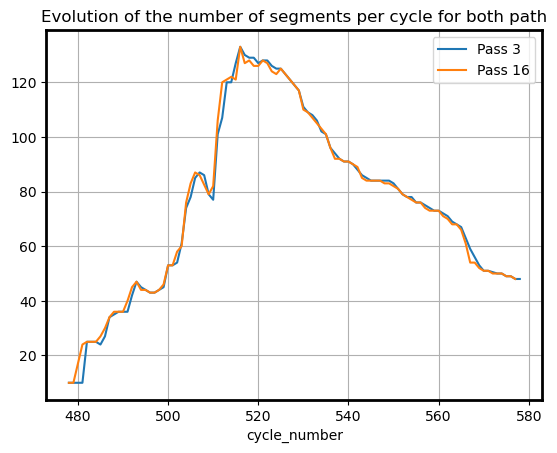

In [8]:
dff = df.groupby(['pass_number','cycle_number']).drifter_id.count()
fig, ax = plt.subplots()
dff.loc[3].plot(label='Pass 3', ax=ax)
dff.loc[16].plot(label='Pass 16', ax=ax)
ax.legend()
ax.set_title('Evolution of the number of segments per cycle for both path')
ax.grid()

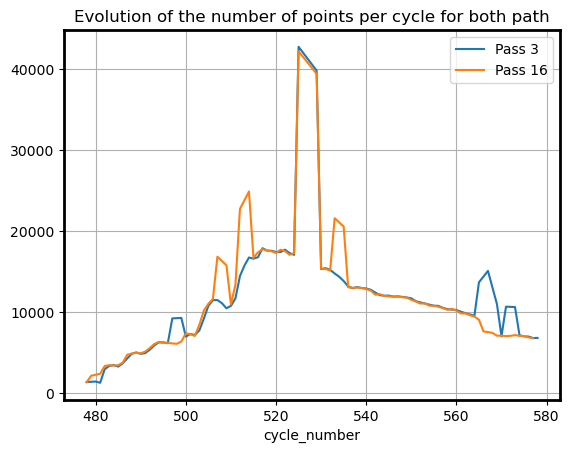

In [9]:
dff = df.groupby(['pass_number','cycle_number']).point_number.sum()
fig, ax = plt.subplots()
dff.loc[3].plot(label='Pass 3', ax=ax)
dff.loc[16].plot(label='Pass 16', ax=ax)
ax.legend()
ax.set_title('Evolution of the number of points per cycle for both path')
ax.grid()

In [10]:
df.point_number.sum()

2068716

<AxesSubplot: >

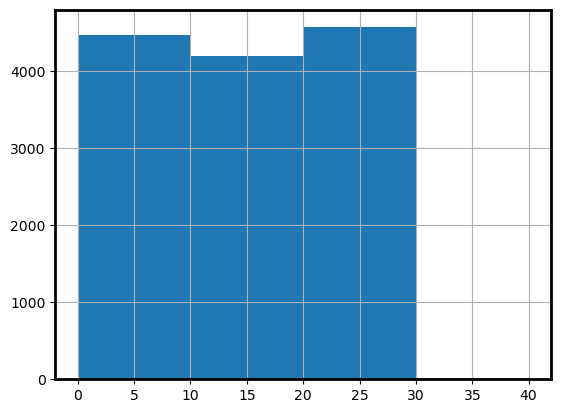

In [ ]:
(df.time_to_swot_min/pd.Timedelta('1min')).hist(bins = np.arange(0,50, 10))